# Delivery Time Regression Notebook with AutoML Integration

This notebook extends the existing modeling workflow by adding:
- manual baseline and tuned model search
- **FLAML** AutoML
- **AutoGluon Tabular** AutoML
- unified validation comparison across all available models
- conditional final refit and test prediction export

It is written to run even when some AutoML libraries are not installed by skipping those sections gracefully.

In [1]:
# =========================
# Imports & Setup
# =========================
import os
import json
import time
import shutil
import joblib
import warnings
import sys
from pathlib import Path
from pprint import pprint

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    KFold,
    cross_val_score
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    VotingRegressor,
    StackingRegressor
)

warnings.filterwarnings("ignore")

# Optional imports
XGBOOST_AVAILABLE = True
try:
    import xgboost as xgb
    from xgboost import XGBRegressor
except Exception:
    XGBOOST_AVAILABLE = False
    xgb = None
    XGBRegressor = None

FLAML_AVAILABLE = True
try:
    from flaml import AutoML as FLAMLAutoML
except Exception:
    FLAML_AVAILABLE = False
    FLAMLAutoML = None

AUTOGLUON_AVAILABLE = True
try:
    from autogluon.tabular import TabularPredictor
except Exception:
    AUTOGLUON_AVAILABLE = False
    TabularPredictor = None

sys.path.append(os.path.abspath(".."))

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

FIG_DIR = Path("../reports/figures")
MODEL_DIR = Path("../models")
REPORT_DIR = Path("../reports")
AUTOGLUON_DIR = MODEL_DIR / "autogluon_delivery_time"

FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
N_JOBS = -1
CV_SPLITS = 5

TARGET = "delivery_time_min"
DROP_COLS = ["order_id", "driver_id", "order_date", "order_time", "pickup_time", "restaurant_latitude", "restaurant_longitude", "delivery_latitude", "delivery_longitude"]

print("Setup complete.")
print(f"XGBoost available   : {XGBOOST_AVAILABLE}")
print(f"FLAML available     : {FLAML_AVAILABLE}")
print(f"AutoGluon available : {AUTOGLUON_AVAILABLE}")

Setup complete.
XGBoost available   : True
FLAML available     : True
AutoGluon available : True


In [2]:
# =========================
# Helper Utilities
# =========================
def save_plot(name: str):
    plt.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight", dpi=300)


def evaluate_regression(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return pd.DataFrame({
        "Model": [model_name],
        "MAE": [mae],
        "RMSE": [rmse],
        "R2": [r2]
    })


def metrics_dict(model_name, y_true, y_pred, cv_rmse_mean=np.nan, cv_rmse_std=np.nan, family="manual"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {
        "Model": model_name,
        "Family": family,
        "CV_RMSE_Mean": cv_rmse_mean,
        "CV_RMSE_STD": cv_rmse_std,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }


def print_metrics(split_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"{split_name} MAE : {mae:.4f}")
    print(f"{split_name} RMSE: {rmse:.4f}")
    print(f"{split_name} R2  : {r2:.4f}")


def build_pipeline(model, preprocessor):
    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])


def get_cv_scores(pipeline, X_data, y_data, cv_obj):
    neg_rmse_scores = cross_val_score(
        pipeline,
        X_data,
        y_data,
        cv=cv_obj,
        scoring="neg_root_mean_squared_error",
        n_jobs=N_JOBS
    )
    return -neg_rmse_scores


def fit_and_evaluate(name, pipeline, X_fit, y_fit, X_eval, y_eval, cv_obj=None, family="manual"):
    result = {}
    if cv_obj is not None:
        cv_rmse_scores = get_cv_scores(pipeline, X_fit, y_fit, cv_obj)
        result["CV_RMSE_Mean"] = cv_rmse_scores.mean()
        result["CV_RMSE_STD"] = cv_rmse_scores.std()
    else:
        result["CV_RMSE_Mean"] = np.nan
        result["CV_RMSE_STD"] = np.nan

    pipeline.fit(X_fit, y_fit)
    preds = pipeline.predict(X_eval)

    result["Model"] = name
    result["Family"] = family
    result["MAE"] = mean_absolute_error(y_eval, preds)
    result["RMSE"] = np.sqrt(mean_squared_error(y_eval, preds))
    result["R2"] = r2_score(y_eval, preds)

    return result, pipeline, preds


class FLAMLRegressorWrapper(BaseEstimator, RegressorMixin):

    def __init__(
        self,
        time_budget=120,
        metric="rmse",
        estimator_list=None,
        seed=42,
        n_jobs=-1,
        task="regression",
        log_file_name="flaml.log",
        eval_method="cv",
        n_splits=3,
        split_ratio=None,
    ):
        self.time_budget = time_budget
        self.metric = metric
        self.estimator_list = estimator_list
        self.seed = seed
        self.n_jobs = n_jobs
        self.task = task
        self.log_file_name = log_file_name
        self.eval_method = eval_method
        self.n_splits = n_splits
        self.split_ratio = split_ratio
        self.automl_ = None

    def fit(self, X, y):
        if not FLAML_AVAILABLE:
            raise ImportError("FLAML is not installed.")
        self.automl_ = FLAMLAutoML()
        settings = {
            "time_budget": self.time_budget,
            "metric": self.metric,
            "task": self.task,
            "seed": self.seed,
            "n_jobs": self.n_jobs,
            "log_file_name": self.log_file_name,
            "eval_method": self.eval_method,
            "n_splits": self.n_splits,
        }
        if self.estimator_list is not None:
            settings["estimator_list"] = self.estimator_list
        if self.split_ratio is not None:
            settings["split_ratio"] = self.split_ratio
        self.automl_.fit(X_train=X, y_train=y, **settings)
        return self

    def predict(self, X):
        return self.automl_.predict(X)

In [3]:
# =========================
# Load Data
# =========================
from src.data_preprocessing import load_clean_data
from src.data_preprocessing import preprocess_pipeline

train_df = load_clean_data("../data/processed/cleaned_delivery_data.csv")

test_df = pd.read_csv("../data/raw/test.csv")
test_df = preprocess_pipeline(test_df)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train shape: (45082, 25)
Test shape : (11270, 24)


In [4]:
# =========================
# Define Target and Features
# =========================
X = train_df.drop(columns=[TARGET])
y = train_df[TARGET]
X_test = test_df.copy()

print("X shape     :", X.shape)
print("y shape     :", y.shape)
print("X_test shape:", X_test.shape)

X shape     : (45082, 24)
y shape     : (45082,)
X_test shape: (11270, 24)


In [5]:
# =========================
# Drop Leakage / Non-Useful Columns
# =========================
X = X.drop(columns=[col for col in DROP_COLS if col in X.columns])
X_test = X_test.drop(columns=[col for col in DROP_COLS if col in X_test.columns])

print("Remaining train columns:", X.columns.tolist())

Remaining train columns: ['driver_age', 'driver_rating', 'weather', 'traffic_density', 'vehicle_condition', 'order_type', 'vehicle_type', 'num_deliveries', 'is_festival', 'city', 'distance_km', 'order_hour', 'order_day', 'is_weekend', 'is_peak_hour']


In [6]:
# =========================
# Train / Validation Split
# =========================
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Train shape      :", X_train.shape)
print("Validation shape :", X_val.shape)
print("External test    :", X_test.shape)

Train shape      : (36065, 15)
Validation shape : (9017, 15)
External test    : (11270, 15)


In [7]:
# =========================
# Column Type Detection
# =========================
numeric_features = X_train.select_dtypes(include=["int64", "float64", "Int64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "string"]).columns.tolist()

print("Numeric features:")
print(numeric_features)
print("\nCategorical features:")
print(categorical_features)

Numeric features:
['driver_age', 'driver_rating', 'vehicle_condition', 'num_deliveries', 'distance_km', 'order_hour', 'is_weekend', 'is_peak_hour']

Categorical features:
['weather', 'traffic_density', 'order_type', 'vehicle_type', 'is_festival', 'city', 'order_day']


In [8]:
# =========================
# Preprocessing
# =========================
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

cv = KFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
FAST_CV = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

print("Preprocessor ready.")

Preprocessor ready.


In [9]:
# =========================
# Baseline Model
# =========================
baseline_pipeline = build_pipeline(DummyRegressor(strategy="mean"), preprocessor)
baseline_pipeline.fit(X_train, y_train)
baseline_val_preds = baseline_pipeline.predict(X_val)

baseline_results = evaluate_regression("Baseline (Mean Predictor)", y_val, baseline_val_preds)
baseline_results

,Model,MAE,RMSE,R2
0,Baseline (Mean Predictor),7.613598,9.371572,-0.000218


In [10]:
# =========================
# Initial Model Zoo
# =========================
base_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "Lasso": Lasso(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=N_JOBS),
    "Extra Trees": ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=N_JOBS),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

if XGBOOST_AVAILABLE:
    base_models["XGBoost"] = XGBRegressor(
        random_state=RANDOM_STATE,
        objective="reg:squarederror",
        eval_metric="rmse",
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=N_JOBS
    )

initial_results = []
initial_fitted_models = {}

for name, model in base_models.items():
    pipeline = build_pipeline(model, preprocessor)
    result, fitted_pipeline, val_preds = fit_and_evaluate(
        name=name,
        pipeline=pipeline,
        X_fit=X_train,
        y_fit=y_train,
        X_eval=X_val,
        y_eval=y_val,
        cv_obj=cv,
        family="manual"
    )

    initial_results.append(result)
    initial_fitted_models[name] = fitted_pipeline

    print(f"\n{name}")
    print(f"CV RMSE Mean: {result['CV_RMSE_Mean']:.4f}")
    print(f"CV RMSE Std : {result['CV_RMSE_STD']:.4f}")
    print_metrics("Validation", y_val, val_preds)

initial_results_df = pd.concat([
    baseline_results.assign(Family="baseline", CV_RMSE_Mean=np.nan, CV_RMSE_STD=np.nan),
    pd.DataFrame(initial_results)
], ignore_index=True)

initial_results_df = initial_results_df.sort_values(by="RMSE").reset_index(drop=True)
initial_results_df


Linear Regression
CV RMSE Mean: 6.0169
CV RMSE Std : 0.0319
Validation MAE : 4.8056
Validation RMSE: 6.0212
Validation R2  : 0.5871

Ridge
CV RMSE Mean: 6.0169
CV RMSE Std : 0.0319
Validation MAE : 4.8057
Validation RMSE: 6.0212
Validation R2  : 0.5871

Lasso
CV RMSE Mean: 7.7040
CV RMSE Std : 0.0338
Validation MAE : 6.1996
Validation RMSE: 7.6655
Validation R2  : 0.3308

Random Forest
CV RMSE Mean: 4.0176
CV RMSE Std : 0.0404
Validation MAE : 3.1431
Validation RMSE: 3.9636
Validation R2  : 0.8211

Extra Trees
CV RMSE Mean: 4.0824
CV RMSE Std : 0.0345
Validation MAE : 3.1842
Validation RMSE: 4.0488
Validation R2  : 0.8133

Gradient Boosting
CV RMSE Mean: 4.5082
CV RMSE Std : 0.0504
Validation MAE : 3.5744
Validation RMSE: 4.4677
Validation R2  : 0.7727

XGBoost
CV RMSE Mean: 3.9448
CV RMSE Std : 0.0290
Validation MAE : 3.1098
Validation RMSE: 3.9023
Validation R2  : 0.8266


,Model,MAE,RMSE,R2,Family,CV_RMSE_Mean,CV_RMSE_STD
0,XGBoost,3.109757,3.902295,0.826576,manual,3.944823,0.029017
1,Random Forest,3.143122,3.963642,0.821080,manual,4.017589,0.040435
2,Extra Trees,3.184239,4.048787,0.813311,manual,4.082398,0.034459
3,Gradient Boosting,3.574438,4.467718,0.772678,manual,4.508174,0.050420
4,Ridge,4.805656,6.021211,0.587107,manual,6.016913,0.031898
5,Linear Regression,4.805627,6.021232,0.587104,manual,6.016919,0.031930
6,Lasso,6.199553,7.665538,0.330801,manual,7.704006,0.033779
7,Baseline (Mean Predictor),7.613598,9.371572,-0.000218,baseline,NaN,NaN


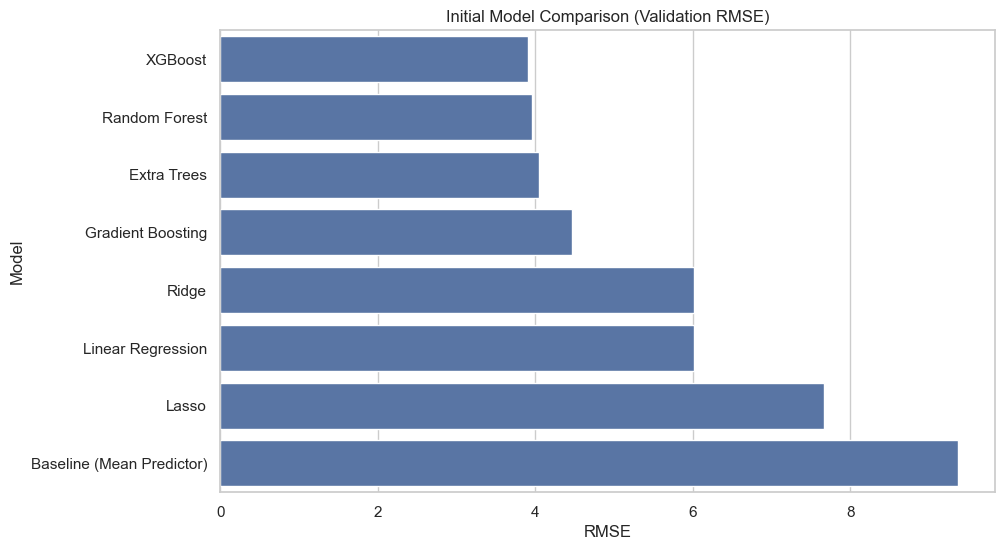

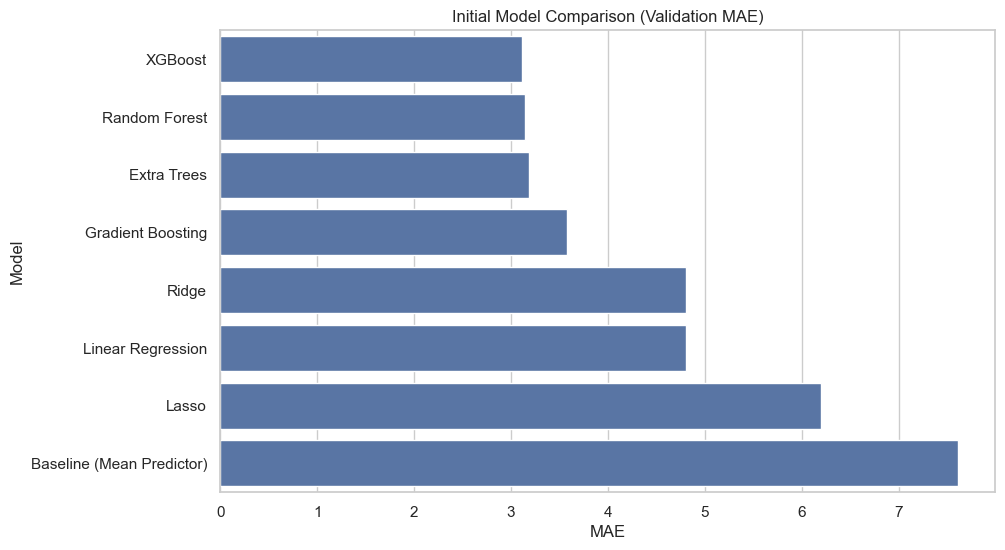

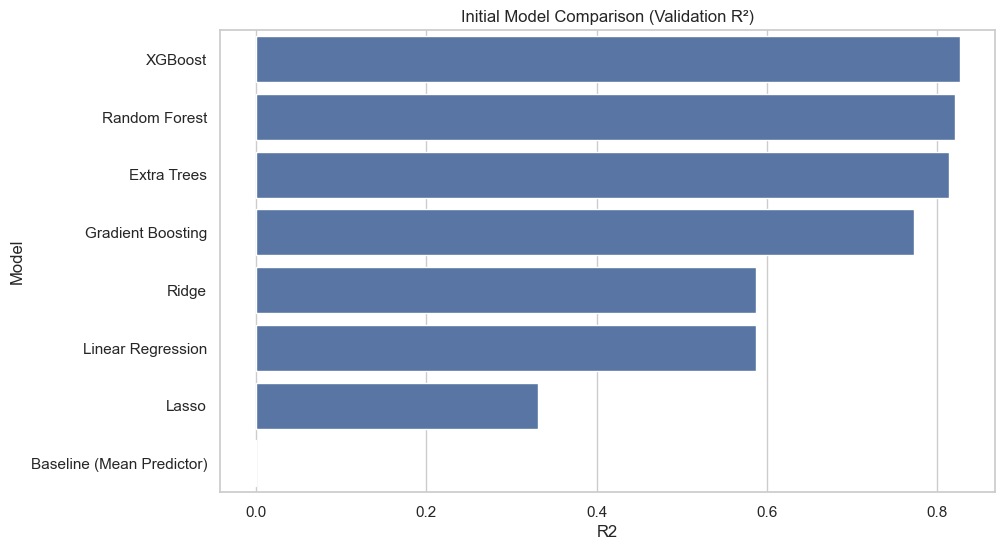

In [11]:
# =========================
# Visual Comparison of Initial Models
# =========================
plt.figure(figsize=(10, 6))
sns.barplot(data=initial_results_df, x="RMSE", y="Model")
plt.title("Initial Model Comparison (Validation RMSE)")
save_plot("automl_initial_model_comparison_rmse")
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=initial_results_df, x="MAE", y="Model")
plt.title("Initial Model Comparison (Validation MAE)")
save_plot("automl_initial_model_comparison_mae")
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=initial_results_df, x="R2", y="Model")
plt.title("Initial Model Comparison (Validation R²)")
save_plot("automl_initial_model_comparison_r2")
plt.show()

In [12]:
# =========================
# Select Top Models for Manual Tuning
# =========================
TOP_K = 3

top_models = (
    initial_results_df
    .sort_values(by="RMSE")
    .head(TOP_K)["Model"]
    .tolist()
)

print("Selected models for tuning:", top_models)

Selected models for tuning: ['XGBoost', 'Random Forest', 'Extra Trees']


In [13]:
# =========================
# Search Spaces
# =========================
search_spaces = {
    "Random Forest": {
        "model": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=N_JOBS),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [None, 10, 20],
            "model__min_samples_split": [2, 5],
            "model__min_samples_leaf": [1, 2]
        },
        "n_iter": 10
    },
    "Extra Trees": {
        "model": ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=N_JOBS),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [None, 10, 20],
            "model__min_samples_split": [2, 5],
            "model__min_samples_leaf": [1, 2]
        },
        "n_iter": 10
    },
    "Gradient Boosting": {
        "model": GradientBoostingRegressor(random_state=RANDOM_STATE),
        "params": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_depth": [2, 3, 4],
            "model__subsample": [0.8, 1.0]
        },
        "n_iter": 10
    },
}

if XGBOOST_AVAILABLE:
    search_spaces["XGBoost"] = {
        "model": XGBRegressor(
            random_state=RANDOM_STATE,
            objective="reg:squarederror",
            eval_metric="rmse",
            n_jobs=N_JOBS,
            tree_method="hist"
        ),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [4, 6],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0]
        },
        "n_iter": 10
    }

filtered_search_spaces = {
    name: cfg for name, cfg in search_spaces.items()
    if name in top_models
}

filtered_search_spaces.keys()

dict_keys(['Random Forest', 'Extra Trees', 'XGBoost'])

In [14]:
# =========================
# Hyperparameter Tuning Loop
# =========================
tuned_models = {}
tuning_summary = {}

for model_name, cfg in filtered_search_spaces.items():
    print("\n" + "=" * 80)
    print(f"Tuning: {model_name}")
    print("=" * 80)

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", cfg["model"])
    ])

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=cfg["params"],
        n_iter=cfg["n_iter"],
        scoring="neg_root_mean_squared_error",
        cv=FAST_CV,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
        verbose=1
    )

    search.fit(X_train, y_train)

    best_estimator = search.best_estimator_
    best_params = search.best_params_
    best_cv_rmse = -search.best_score_

    val_preds = best_estimator.predict(X_val)

    val_mae = mean_absolute_error(y_val, val_preds)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
    val_r2 = r2_score(y_val, val_preds)

    tuned_name = f"{model_name} Tuned"
    tuned_models[tuned_name] = best_estimator

    tuning_summary[tuned_name] = {
        "Model": tuned_name,
        "Family": "manual_tuned",
        "CV_RMSE_Mean": best_cv_rmse,
        "CV_RMSE_STD": np.nan,
        "MAE": val_mae,
        "RMSE": val_rmse,
        "R2": val_r2,
        "Best_Params": best_params
    }

    print("Best Params:")
    pprint(best_params)
    print(f"Best CV RMSE: {best_cv_rmse:.4f}")
    print_metrics("Validation", y_val, val_preds)

tuned_results_df = (
    pd.DataFrame(tuning_summary.values())
    .sort_values(by="RMSE")
    .reset_index(drop=True)
)

tuned_results_df


Tuning: Random Forest
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Params:
{'model__max_depth': 20,
 'model__min_samples_leaf': 2,
 'model__min_samples_split': 2,
 'model__n_estimators': 200}
Best CV RMSE: 4.0100
Validation MAE : 3.1251
Validation RMSE: 3.9343
Validation R2  : 0.8237

Tuning: Extra Trees
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Params:
{'model__max_depth': 20,
 'model__min_samples_leaf': 2,
 'model__min_samples_split': 2,
 'model__n_estimators': 200}
Best CV RMSE: 4.0306
Validation MAE : 3.1347
Validation RMSE: 3.9581
Validation R2  : 0.8216

Tuning: XGBoost
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Params:
{'model__colsample_bytree': 1.0,
 'model__learning_rate': 0.05,
 'model__max_depth': 6,
 'model__n_estimators': 100,
 'model__subsample': 1.0}
Best CV RMSE: 4.0191
Validation MAE : 3.1656
Validation RMSE: 3.9658
Validation R2  : 0.8209


,Model,Family,CV_RMSE_Mean,CV_RMSE_STD,MAE,RMSE,R2,Best_Params
0,Random Forest Tuned,manual_tuned,4.010012,NaN,3.125053,3.934295,0.823720,"{'model__n_estimators': 200, 'model__min_sampl..."
1,Extra Trees Tuned,manual_tuned,4.030596,NaN,3.134682,3.958081,0.821582,"{'model__n_estimators': 200, 'model__min_sampl..."
2,XGBoost Tuned,manual_tuned,4.019058,NaN,3.165583,3.965767,0.820888,"{'model__subsample': 1.0, 'model__n_estimators..."


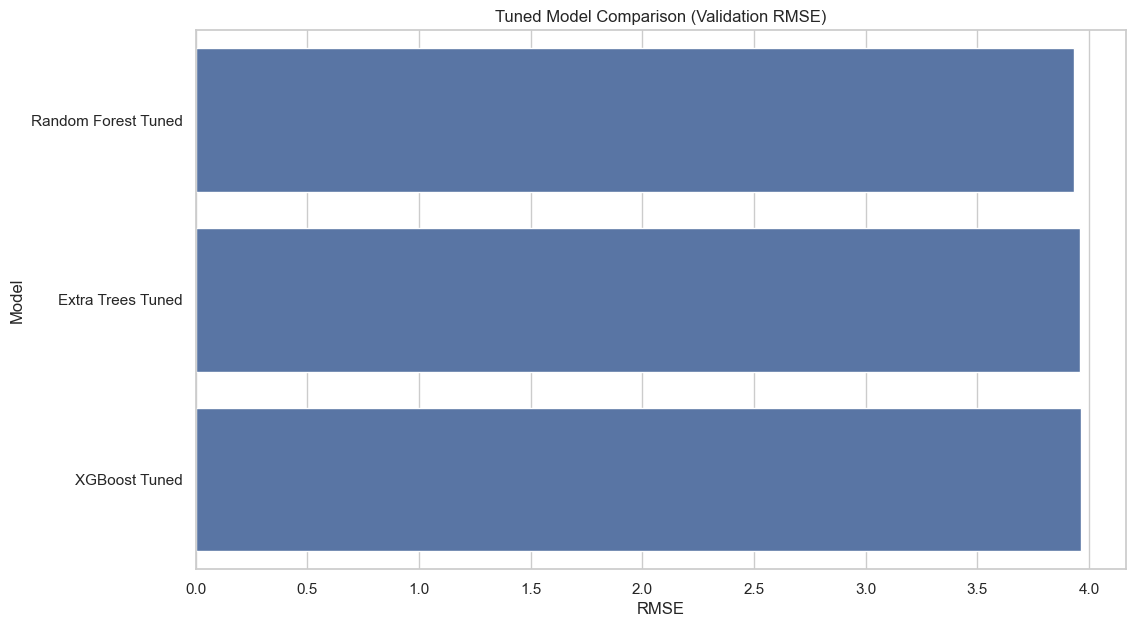

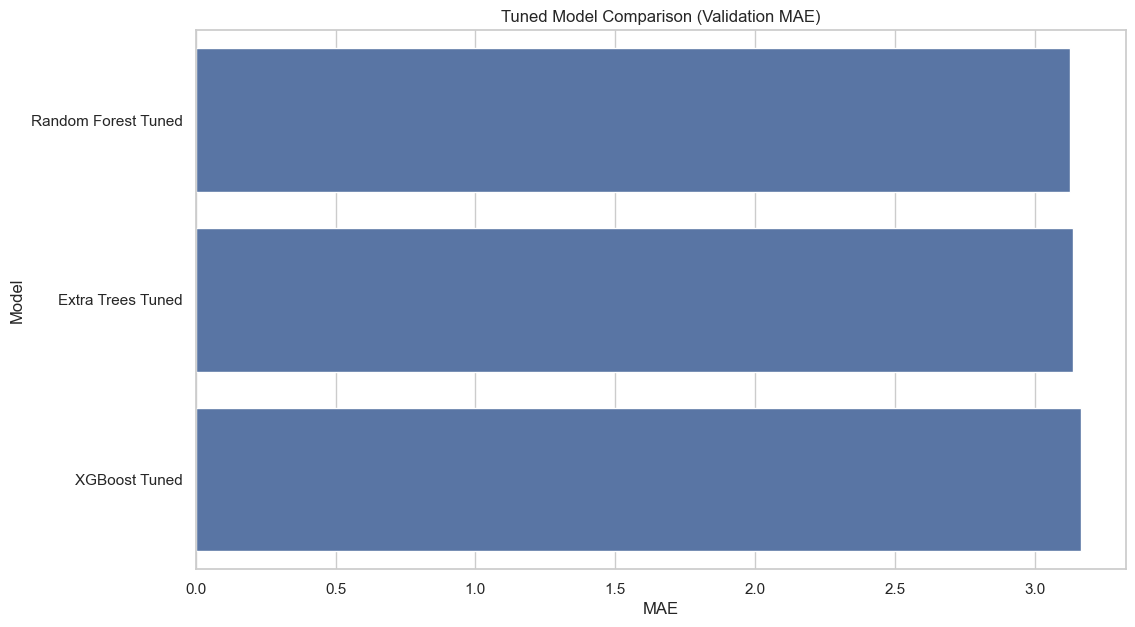

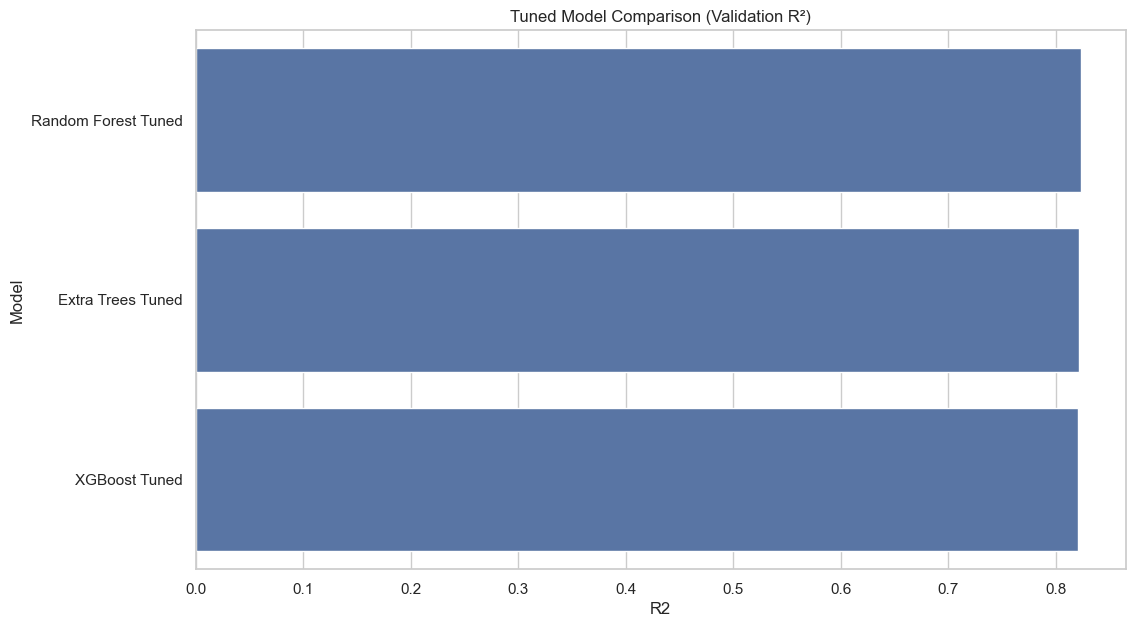

In [15]:
# =========================
# Visual Comparison of Tuned Models
# =========================
if not tuned_results_df.empty:
    plt.figure(figsize=(12, 7))
    sns.barplot(data=tuned_results_df, x="RMSE", y="Model")
    plt.title("Tuned Model Comparison (Validation RMSE)")
    save_plot("automl_tuned_model_comparison_rmse")
    plt.show()

    plt.figure(figsize=(12, 7))
    sns.barplot(data=tuned_results_df, x="MAE", y="Model")
    plt.title("Tuned Model Comparison (Validation MAE)")
    save_plot("automl_tuned_model_comparison_mae")
    plt.show()

    plt.figure(figsize=(12, 7))
    sns.barplot(data=tuned_results_df, x="R2", y="Model")
    plt.title("Tuned Model Comparison (Validation R²)")
    save_plot("automl_tuned_model_comparison_r2")
    plt.show()
else:
    print("No tuned models available.")

In [16]:
# =========================
# Top 3 Tuned Models for Ensembling
# =========================
top_3_df = tuned_results_df.head(3).copy()
top_3_names = top_3_df["Model"].tolist()

print("Top tuned models based on validation RMSE:")
for i, name in enumerate(top_3_names, start=1):
    print(f"{i}. {name}")

top_3_df

Top tuned models based on validation RMSE:
1. Random Forest Tuned
2. Extra Trees Tuned
3. XGBoost Tuned


,Model,Family,CV_RMSE_Mean,CV_RMSE_STD,MAE,RMSE,R2,Best_Params
0,Random Forest Tuned,manual_tuned,4.010012,NaN,3.125053,3.934295,0.823720,"{'model__n_estimators': 200, 'model__min_sampl..."
1,Extra Trees Tuned,manual_tuned,4.030596,NaN,3.134682,3.958081,0.821582,"{'model__n_estimators': 200, 'model__min_sampl..."
2,XGBoost Tuned,manual_tuned,4.019058,NaN,3.165583,3.965767,0.820888,"{'model__subsample': 1.0, 'model__n_estimators..."


In [17]:
# =========================
# Build Ensemble Estimators
# =========================
ensemble_estimators = []
for idx, model_name in enumerate(top_3_names, start=1):
    short_name = f"m{idx}"
    estimator = tuned_models[model_name].named_steps["model"]
    ensemble_estimators.append((short_name, estimator))

print("Ensemble estimators:")
print(ensemble_estimators)

Ensemble estimators:
[('m1', RandomForestRegressor(max_depth=20, min_samples_leaf=2, n_estimators=200,
                      n_jobs=-1, random_state=42)), ('m2', ExtraTreesRegressor(max_depth=20, min_samples_leaf=2, n_estimators=200,
                    n_jobs=-1, random_state=42)), ('m3', XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jo

In [18]:
# =========================
# Ensemble 1: VotingRegressor
# =========================
voting_result = None
voting_fitted_pipeline = None
voting_val_preds = None

if len(ensemble_estimators) >= 2:
    voting_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", VotingRegressor(estimators=ensemble_estimators, n_jobs=N_JOBS))
    ])

    voting_result, voting_fitted_pipeline, voting_val_preds = fit_and_evaluate(
        name="Voting Ensemble (Top 3)",
        pipeline=voting_pipeline,
        X_fit=X_train,
        y_fit=y_train,
        X_eval=X_val,
        y_eval=y_val,
        cv_obj=cv,
        family="ensemble"
    )

    print("Voting Ensemble Results")
    print_metrics("Validation", y_val, voting_val_preds)
    display(pd.DataFrame([voting_result]))
else:
    print("Skipping VotingRegressor: fewer than 2 tuned estimators available.")

Voting Ensemble Results
Validation MAE : 3.0651
Validation RMSE: 3.8428
Validation R2  : 0.8318


,CV_RMSE_Mean,CV_RMSE_STD,Model,Family,MAE,RMSE,R2
0,3.886935,0.038002,Voting Ensemble (Top 3),ensemble,3.065093,3.8428,0.831824


In [19]:
# =========================
# Ensemble 2: StackingRegressor
# =========================
stacking_result = None
stacking_fitted_pipeline = None
stacking_val_preds = None

if len(ensemble_estimators) >= 2:
    stacking_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            StackingRegressor(
                estimators=ensemble_estimators,
                final_estimator=Ridge(alpha=1.0, random_state=RANDOM_STATE),
                cv=5,
                n_jobs=N_JOBS,
                passthrough=False
            )
        )
    ])

    stacking_result, stacking_fitted_pipeline, stacking_val_preds = fit_and_evaluate(
        name="Stacking Ensemble (Top 3)",
        pipeline=stacking_pipeline,
        X_fit=X_train,
        y_fit=y_train,
        X_eval=X_val,
        y_eval=y_val,
        cv_obj=cv,
        family="ensemble"
    )

    print("Stacking Ensemble Results")
    print_metrics("Validation", y_val, stacking_val_preds)
    display(pd.DataFrame([stacking_result]))
else:
    print("Skipping StackingRegressor: fewer than 2 tuned estimators available.")

Stacking Ensemble Results
Validation MAE : 3.0645
Validation RMSE: 3.8370
Validation R2  : 0.8323


,CV_RMSE_Mean,CV_RMSE_STD,Model,Family,MAE,RMSE,R2
0,3.879397,0.036756,Stacking Ensemble (Top 3),ensemble,3.064455,3.836959,0.832334


In [20]:
# =========================
# AutoML 1: FLAML
# =========================
flaml_results_df = pd.DataFrame()
flaml_model = None
flaml_val_preds = None
flaml_summary = {}

if FLAML_AVAILABLE:
    flaml_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", FLAMLRegressorWrapper(
            time_budget=120,
            metric="rmse",
            estimator_list=["lgbm", "xgboost", "xgb_limitdepth", "rf", "extra_tree"],
            seed=RANDOM_STATE,
            n_jobs=N_JOBS,
            eval_method="cv",
            n_splits=3,
            log_file_name=str(MODEL_DIR / "flaml_training.log")
        ))
    ])

    start_time = time.time()
    flaml_pipeline.fit(X_train, y_train)
    flaml_train_seconds = time.time() - start_time

    flaml_val_preds = flaml_pipeline.predict(X_val)
    flaml_automl = flaml_pipeline.named_steps["model"].automl_

    flaml_best_estimator = getattr(flaml_automl, "best_estimator", None)
    flaml_best_config = getattr(flaml_automl, "best_config", None)
    flaml_best_loss = getattr(flaml_automl, "best_loss", np.nan)

    flaml_summary = {
        "Model": "FLAML AutoML",
        "Family": "automl_flaml",
        "CV_RMSE_Mean": flaml_best_loss if pd.notnull(flaml_best_loss) else np.nan,
        "CV_RMSE_STD": np.nan,
        "MAE": mean_absolute_error(y_val, flaml_val_preds),
        "RMSE": np.sqrt(mean_squared_error(y_val, flaml_val_preds)),
        "R2": r2_score(y_val, flaml_val_preds),
        "Train_Seconds": flaml_train_seconds,
        "Best_Estimator": flaml_best_estimator,
        "Best_Config": flaml_best_config
    }

    flaml_model = flaml_pipeline
    flaml_results_df = pd.DataFrame([flaml_summary])

    print("FLAML finished.")
    print("Best estimator:", flaml_best_estimator)
    print("Best config:")
    pprint(flaml_best_config)
    print_metrics("Validation", y_val, flaml_val_preds)
    display(flaml_results_df)
else:
    print("FLAML not installed. Skipping.")

[flaml.automl.logger: 03-30 00:28:28] {2375} INFO - task = regression
[flaml.automl.logger: 03-30 00:28:28] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 03-30 00:28:28] {2489} INFO - Minimizing error metric: rmse
[flaml.automl.logger: 03-30 00:28:28] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'xgboost', 'xgb_limitdepth', 'rf', 'extra_tree']
[flaml.automl.logger: 03-30 00:28:28] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 03-30 00:28:28] {3046} INFO - Estimated sufficient time budget=1742s. Estimated necessary time budget=12s.
[flaml.automl.logger: 03-30 00:28:28] {3097} INFO -  at 0.3s,	estimator lgbm's best error=8.3301e+00,	best estimator lgbm's best error=8.3301e+00
[flaml.automl.logger: 03-30 00:28:28] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 03-30 00:28:28] {3097} INFO -  at 0.5s,	estimator lgbm's best error=8.3301e+00,	best estimator lgbm's best error=8.3301e+00
[flaml.automl.logger: 03-30 00:28:28

,Model,Family,CV_RMSE_Mean,CV_RMSE_STD,MAE,RMSE,R2,Train_Seconds,Best_Estimator,Best_Config
0,FLAML AutoML,automl_flaml,3.863097,NaN,3.047727,3.790766,0.836347,121.198131,rf,"{'n_estimators': 102, 'max_features': 0.462582..."


In [21]:
# =========================
# Unified Final Comparison
# =========================
comparison_frames = [
    baseline_results.assign(Family="baseline", CV_RMSE_Mean=np.nan, CV_RMSE_STD=np.nan)
]

if not tuned_results_df.empty:
    comparison_frames.append(tuned_results_df.drop(columns=["Best_Params"], errors="ignore"))

if voting_result is not None:
    comparison_frames.append(pd.DataFrame([voting_result]))

if stacking_result is not None:
    comparison_frames.append(pd.DataFrame([stacking_result]))

if not flaml_results_df.empty:
    comparison_frames.append(flaml_results_df)


final_results_df = pd.concat(comparison_frames, ignore_index=True)
final_results_df = final_results_df.sort_values(by="RMSE").reset_index(drop=True)

final_results_df

,Model,MAE,RMSE,R2,Family,CV_RMSE_Mean,CV_RMSE_STD,Train_Seconds,Best_Estimator,Best_Config
0,FLAML AutoML,3.047727,3.790766,0.836347,automl_flaml,3.863097,NaN,121.198131,rf,"{'n_estimators': 102, 'max_features': 0.462582..."
1,Stacking Ensemble (Top 3),3.064455,3.836959,0.832334,ensemble,3.879397,0.036756,NaN,NaN,NaN
2,Voting Ensemble (Top 3),3.065093,3.842800,0.831824,ensemble,3.886935,0.038002,NaN,NaN,NaN
3,Random Forest Tuned,3.125053,3.934295,0.823720,manual_tuned,4.010012,NaN,NaN,NaN,NaN
4,Extra Trees Tuned,3.134682,3.958081,0.821582,manual_tuned,4.030596,NaN,NaN,NaN,NaN
5,XGBoost Tuned,3.165583,3.965767,0.820888,manual_tuned,4.019058,NaN,NaN,NaN,NaN
6,Baseline (Mean Predictor),7.613598,9.371572,-0.000218,baseline,NaN,NaN,NaN,NaN,NaN


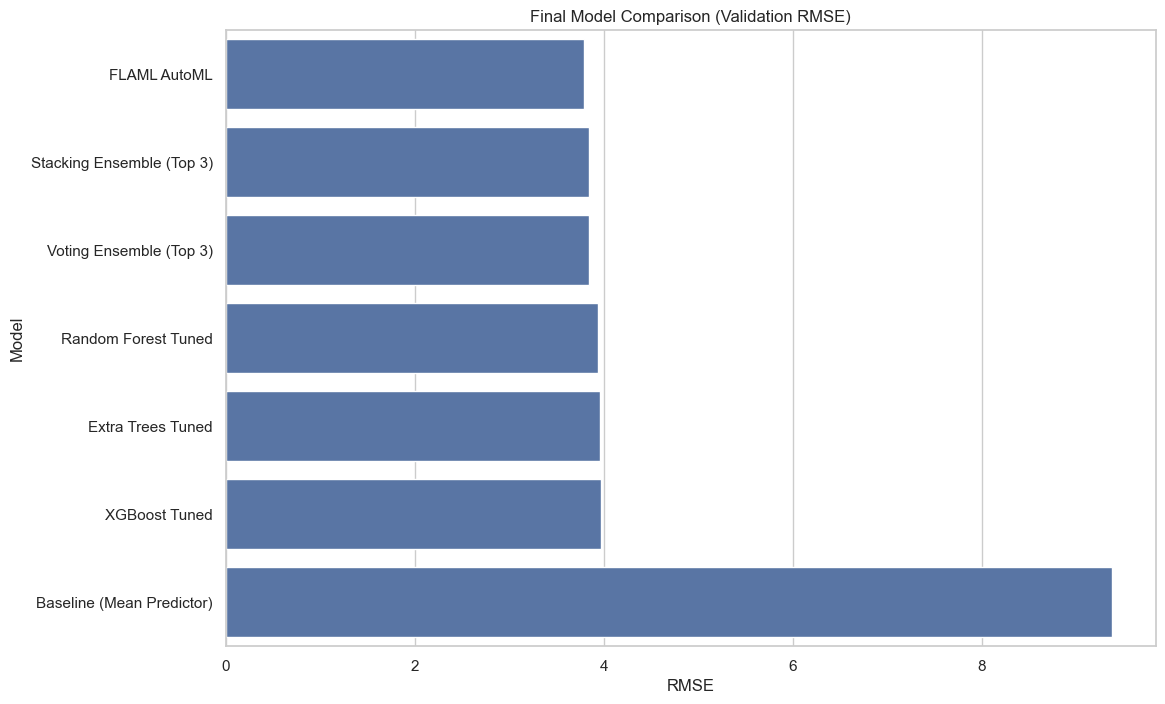

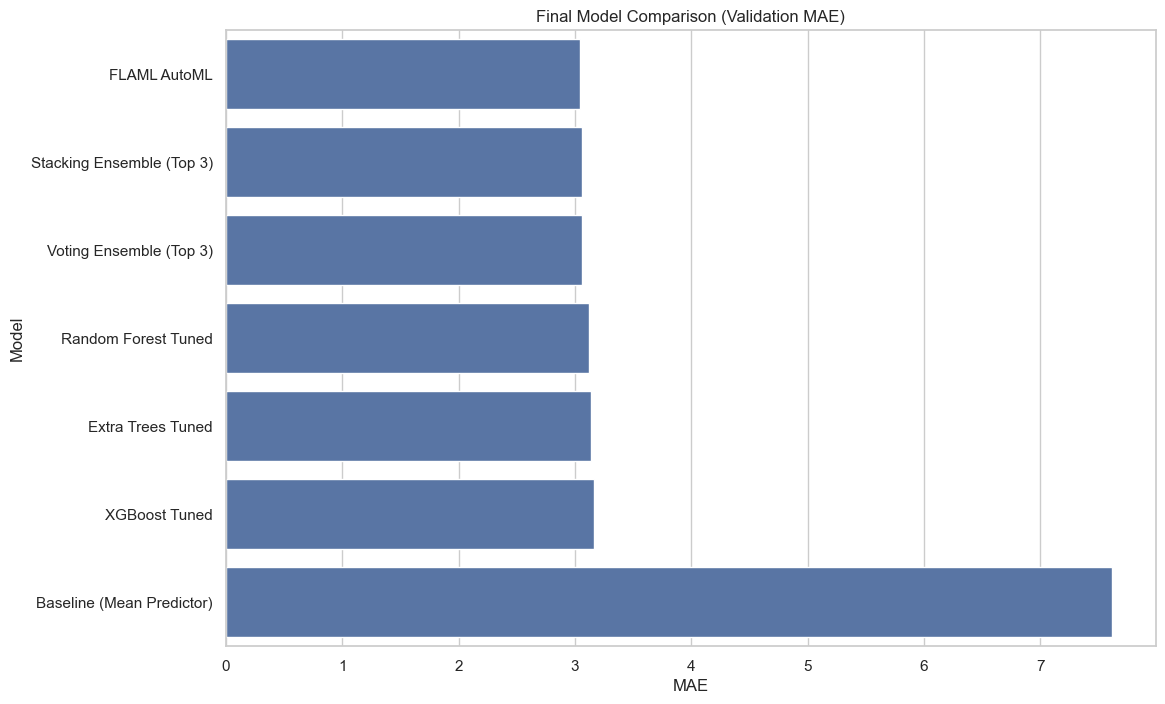

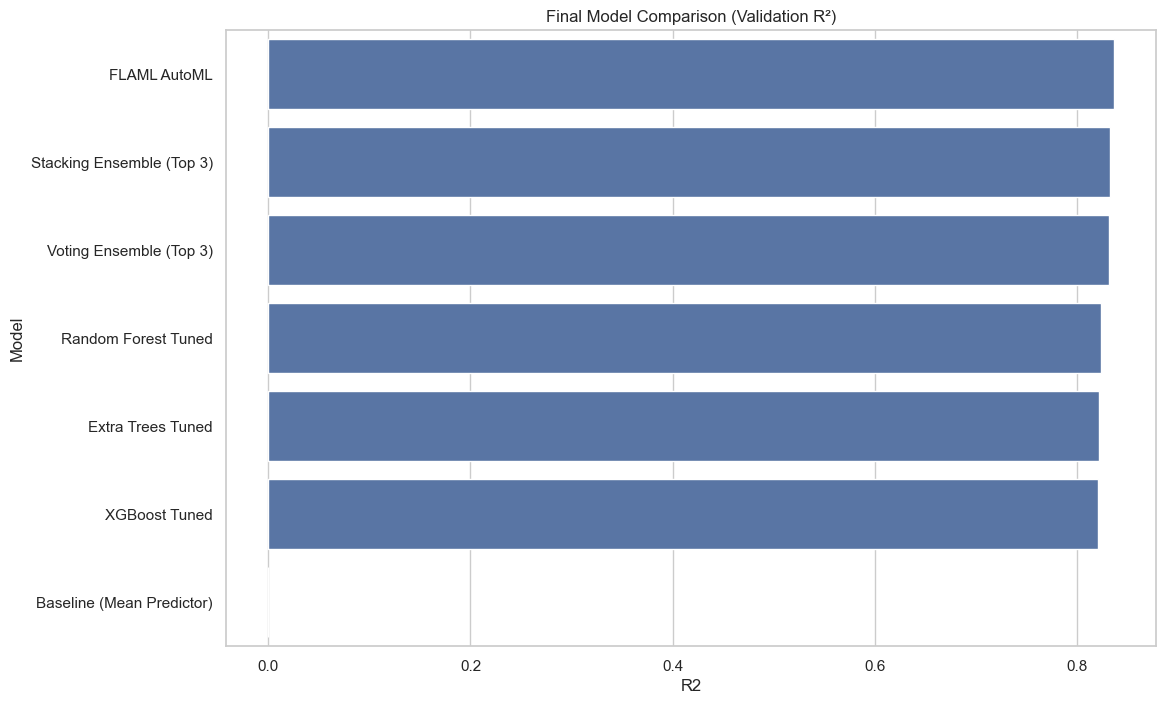

In [22]:
# =========================
# Visual Final Comparison
# =========================
plt.figure(figsize=(12, 8))
sns.barplot(data=final_results_df, x="RMSE", y="Model")
plt.title("Final Model Comparison (Validation RMSE)")
save_plot("automl_final_model_comparison_rmse")
plt.show()

plt.figure(figsize=(12, 8))
sns.barplot(data=final_results_df, x="MAE", y="Model")
plt.title("Final Model Comparison (Validation MAE)")
save_plot("automl_final_model_comparison_mae")
plt.show()

plt.figure(figsize=(12, 8))
sns.barplot(data=final_results_df, x="R2", y="Model")
plt.title("Final Model Comparison (Validation R²)")
save_plot("automl_final_model_comparison_r2")
plt.show()

In [23]:
# =========================
# Model Registry
# =========================
model_registry = {
    "Baseline (Mean Predictor)": {"family": "baseline", "type": "sklearn", "object": baseline_pipeline},
}

for name, pipeline in tuned_models.items():
    model_registry[name] = {"family": "manual_tuned", "type": "sklearn", "object": pipeline}

if voting_fitted_pipeline is not None:
    model_registry["Voting Ensemble (Top 3)"] = {"family": "ensemble", "type": "sklearn", "object": voting_fitted_pipeline}

if stacking_fitted_pipeline is not None:
    model_registry["Stacking Ensemble (Top 3)"] = {"family": "ensemble", "type": "sklearn", "object": stacking_fitted_pipeline}

if flaml_model is not None:
    model_registry["FLAML AutoML"] = {"family": "automl_flaml", "type": "sklearn", "object": flaml_model}


best_model_name = final_results_df.iloc[0]["Model"]
best_model_entry = model_registry[best_model_name]

print("Best overall model based on validation RMSE:", best_model_name)
print("Best model type:", best_model_entry["type"])

Best overall model based on validation RMSE: FLAML AutoML
Best model type: sklearn


In [24]:
# =========================
# Save Honest Validation Model / Artifacts
# =========================
if best_model_entry["type"] == "sklearn":
    val_model_pipeline = best_model_entry["object"]
    joblib.dump(val_model_pipeline, MODEL_DIR / "model_validation.pkl")
    print(f"Saved validation model to {MODEL_DIR / 'model_validation.pkl'}")
elif best_model_entry["type"] == "autogluon":
    val_model_pipeline = None
    print("Best validation model is AutoGluon. Artifacts already saved in:")
    print(AUTOGLUON_DIR)
else:
    val_model_pipeline = None
    print("Validation artifact save not implemented for this model type.")

Saved validation model to ..\models\model_validation.pkl


In [25]:
# =========================
# Validation Diagnostics on Selected Best Model
# =========================
if best_model_entry["type"] == "sklearn":
    val_preds = best_model_entry["object"].predict(X_val)
elif best_model_entry["type"] == "autogluon":
    val_preds = best_model_entry["object"].predict(X_val)
else:
    raise ValueError("Unsupported model type in registry.")

print_metrics("Validation", y_val, val_preds)

Validation MAE : 3.0477
Validation RMSE: 3.7908
Validation R2  : 0.8363


In [ ]:
# =========================
# Save validation predictions (actual vs predicted) for reporting / Power BI
# =========================
val_export = pd.DataFrame({
    "split": "validation",
    "order_id": train_df.loc[X_val.index, "order_id"].astype(str).values,
    "delivery_time_min": y_val.values,
    "predicted_delivery_time_min": np.asarray(val_preds, dtype=float),
})
val_export["error"] = val_export["predicted_delivery_time_min"] - val_export["delivery_time_min"]
val_export["abs_error"] = val_export["error"].abs()
val_export["best_model_name"] = best_model_name

for col in ["city", "distance_km", "traffic_density", "weather"]:
    if col in X_val.columns:
        val_export[col] = X_val[col].values

val_path = REPORT_DIR / "validation_predictions.csv"
val_export.to_csv(val_path, index=False)
print(f"Saved validation predictions to {val_path}")

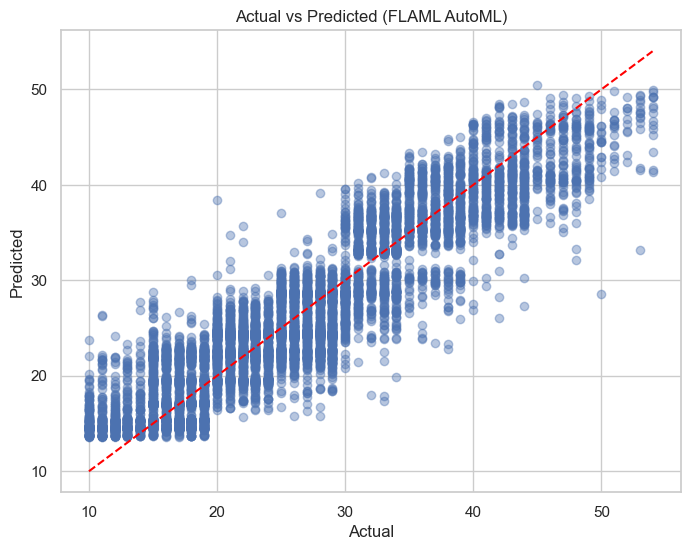

In [26]:
# =========================
# Actual vs Predicted
# =========================
plt.figure(figsize=(8, 6))
plt.scatter(y_val, val_preds, alpha=0.4)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted ({best_model_name})")
plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    linestyle="--", color="red"
)
save_plot("automl_actual_vs_predicted_validation")
plt.show()

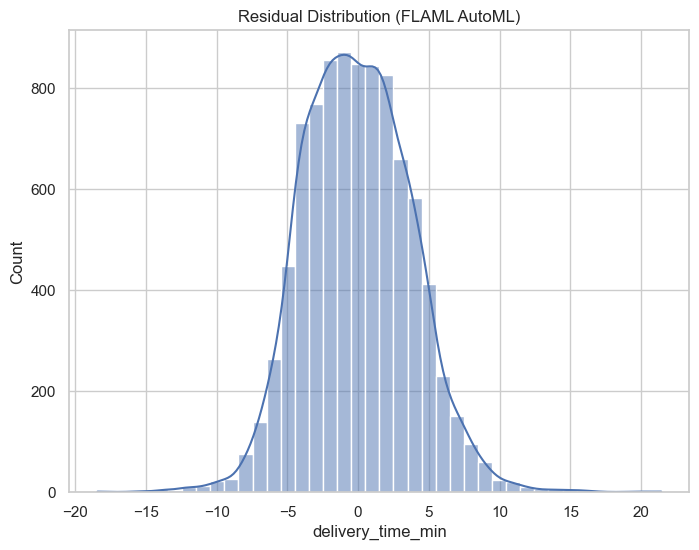

In [27]:
# =========================
# Residual Distribution
# =========================
residuals = y_val - val_preds

plt.figure(figsize=(8, 6))
sns.histplot(residuals, bins=40, kde=True)
plt.title(f"Residual Distribution ({best_model_name})")
save_plot("automl_residuals_validation")
plt.show()

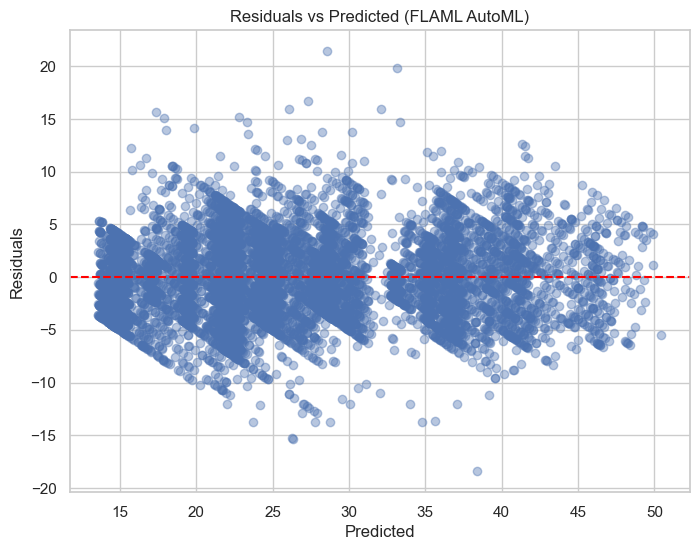

In [28]:
# =========================
# Residuals vs Predicted
# =========================
plt.figure(figsize=(8, 6))
plt.scatter(val_preds, residuals, alpha=0.4)
plt.axhline(0, linestyle="--", color="red")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title(f"Residuals vs Predicted ({best_model_name})")
save_plot("automl_residuals_vs_predicted_validation")
plt.show()

In [29]:
# =========================
# Feature Importance (when exposed)
# =========================
importance_df = None

if best_model_entry["type"] == "sklearn":
    model_obj = best_model_entry["object"]
    model_step = model_obj.named_steps["model"]
    preprocessor_step = model_obj.named_steps["preprocessor"]
    feature_names = preprocessor_step.get_feature_names_out()

    if hasattr(model_step, "feature_importances_"):
        importances = model_step.feature_importances_
        importance_df = pd.DataFrame({
            "feature": feature_names,
            "importance": importances
        }).sort_values(by="importance", ascending=False)

        top_n = 20
        plt.figure(figsize=(10, 8))
        sns.barplot(data=importance_df.head(top_n), x="importance", y="feature")
        plt.title(f"Top {top_n} Feature Importances ({best_model_name})")
        save_plot("automl_top_feature_importances")
        plt.show()

        display(importance_df.head(top_n))
    else:
        print("Selected best model does not expose feature_importances_.")
elif best_model_entry["type"] == "autogluon":
    print("For AutoGluon, use predictor.feature_importance(...) on a labeled dataframe if desired.")

Selected best model does not expose feature_importances_.


In [30]:
# =========================
# Refit Best Model on Full Labeled Data
# =========================
if best_model_entry["type"] == "sklearn":
    final_model_pipeline = clone(best_model_entry["object"])
    final_model_pipeline.fit(X, y)
    print("Refit complete on full labeled dataset for sklearn-compatible model.")
elif best_model_entry["type"] == "autogluon":
    train_full_ag = X.copy()
    train_full_ag[TARGET] = y.values

    full_ag_path = MODEL_DIR / "autogluon_delivery_time_full"
    if full_ag_path.exists():
        shutil.rmtree(full_ag_path)

    final_model_pipeline = TabularPredictor(
        label=TARGET,
        problem_type="regression",
        eval_metric="root_mean_squared_error",
        path=str(full_ag_path)
    ).fit(
        train_data=train_full_ag,
        presets="best_quality",
        time_limit=300,
        num_stack_levels=1,
        num_bag_folds=5,
        verbosity=2
    )
    print("Refit complete on full labeled dataset for AutoGluon.")
else:
    raise ValueError("Unsupported best model type.")

[flaml.automl.logger: 03-30 00:30:33] {2375} INFO - task = regression
[flaml.automl.logger: 03-30 00:30:33] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 03-30 00:30:33] {2489} INFO - Minimizing error metric: rmse
[flaml.automl.logger: 03-30 00:30:33] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'xgboost', 'xgb_limitdepth', 'rf', 'extra_tree']
[flaml.automl.logger: 03-30 00:30:33] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 03-30 00:30:34] {3046} INFO - Estimated sufficient time budget=7619s. Estimated necessary time budget=54s.
[flaml.automl.logger: 03-30 00:30:34] {3097} INFO -  at 0.8s,	estimator lgbm's best error=8.3262e+00,	best estimator lgbm's best error=8.3262e+00
[flaml.automl.logger: 03-30 00:30:34] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 03-30 00:30:35] {3097} INFO -  at 1.5s,	estimator lgbm's best error=8.3262e+00,	best estimator lgbm's best error=8.3262e+00
[flaml.automl.logger: 03-30 00:30:35

In [31]:
# =========================
# Final Prediction on Test Set
# =========================
test_predictions = final_model_pipeline.predict(X_test)

print("Sample predictions:")
print(np.array(test_predictions[:10]))

Sample predictions:
[17.94986424 30.34769907 29.30660638 30.3339159  22.60938896 19.63235039
 13.41336073 21.53330564 41.51234836 25.36891184]


In [32]:
# =========================
# Save Predictions
# =========================
submission = test_df.copy()
submission["predicted_delivery_time_min"] = test_predictions

submission_path = REPORT_DIR / "test_predictions.csv"
submission.to_csv(submission_path, index=False)

print(f"Predictions saved to {submission_path}")

Predictions saved to ..\reports\test_predictions.csv


In [33]:
# =========================
# Save Final Full-Data Model
# =========================
if isinstance(final_model_pipeline, Pipeline):
    joblib.dump(final_model_pipeline, MODEL_DIR / "model_full.pkl")
    print(f"Saved final full-data model to {MODEL_DIR / 'model_full.pkl'}")
else:
    print("Final model is AutoGluon; saved under its predictor path.")

Saved final full-data model to ..\models\model_full.pkl


In [34]:
# =========================
# Save Model Metadata
# =========================
model_metadata = {
    "best_model_name": best_model_name,
    "best_model_family": best_model_entry["family"],
    "best_model_type": best_model_entry["type"],
    "target": TARGET,
    "n_train_rows": int(X.shape[0]),
    "n_test_rows": int(X_test.shape[0]),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "selected_features_used": list(X.columns),
    "top_3_models_for_ensemble": top_3_names,
    "val_mae": float(mean_absolute_error(y_val, val_preds)),
    "val_rmse": float(np.sqrt(mean_squared_error(y_val, val_preds))),
    "val_r2": float(r2_score(y_val, val_preds)),
    "automl_available": {
        "xgboost": XGBOOST_AVAILABLE,
        "flaml": FLAML_AVAILABLE,
        "autogluon": AUTOGLUON_AVAILABLE
    }
}

with open(MODEL_DIR / "model_metadata.json", "w") as f:
    json.dump(model_metadata, f, indent=4)

print(f"Saved metadata to {MODEL_DIR / 'model_metadata.json'}")

Saved metadata to ..\models\model_metadata.json


In [36]:
# =========================
# Save Summary Tables
# =========================
initial_results_df.to_csv(REPORT_DIR / "automl_initial_results.csv", index=False)
tuned_results_df.to_csv(REPORT_DIR / "automl_tuned_results.csv", index=False)

flaml_results_df.to_csv(REPORT_DIR / "automl_flaml_results.csv", index=False)

final_results_df.to_csv(REPORT_DIR / "automl_final_results.csv", index=False)

print("Saved summary tables.")

Saved summary tables.


In [37]:
# =========================
# Example Prediction
# =========================
sample_input = X_test.head(5).copy()
sample_predictions = final_model_pipeline.predict(sample_input)

prediction_df = sample_input.copy()
prediction_df["predicted_delivery_time_min"] = sample_predictions
prediction_df.head()

,driver_age,driver_rating,weather,traffic_density,vehicle_condition,order_type,vehicle_type,num_deliveries,is_festival,city,distance_km,order_hour,order_day,is_weekend,is_peak_hour,predicted_delivery_time_min
0,30.0,4.7,Sunny,Low,3,Drinks,electric_scooter,1,No,Metropolitian,6.232373,NaN,Wednesday,0,0,17.949864
1,28.0,4.6,Windy,Jam,0,Snack,motorcycle,1,No,Metropolitian,17.076617,20.0,Tuesday,0,1,30.347699
2,23.0,4.5,Stormy,Jam,0,Drinks,motorcycle,1,No,Metropolitian,13.406029,19.0,Thursday,0,1,29.306606
3,21.0,4.8,Fog,Medium,1,Meal,scooter,1,No,Metropolitian,13.413644,17.0,Saturday,1,0,30.333916
4,31.0,4.6,Sunny,Medium,2,Drinks,scooter,1,No,Metropolitian,17.076259,18.0,Sunday,1,1,22.609389


In [38]:
# =========================
# Final Summary
# =========================
summary_df = final_results_df.copy()
print("Predictions generated on unseen test data (no labels available).")
print("Best selected model:", best_model_name)
summary_df

Predictions generated on unseen test data (no labels available).
Best selected model: FLAML AutoML


,Model,MAE,RMSE,R2,Family,CV_RMSE_Mean,CV_RMSE_STD,Train_Seconds,Best_Estimator,Best_Config
0,FLAML AutoML,3.047727,3.790766,0.836347,automl_flaml,3.863097,NaN,121.198131,rf,"{'n_estimators': 102, 'max_features': 0.462582..."
1,Stacking Ensemble (Top 3),3.064455,3.836959,0.832334,ensemble,3.879397,0.036756,NaN,NaN,NaN
2,Voting Ensemble (Top 3),3.065093,3.842800,0.831824,ensemble,3.886935,0.038002,NaN,NaN,NaN
3,Random Forest Tuned,3.125053,3.934295,0.823720,manual_tuned,4.010012,NaN,NaN,NaN,NaN
4,Extra Trees Tuned,3.134682,3.958081,0.821582,manual_tuned,4.030596,NaN,NaN,NaN,NaN
5,XGBoost Tuned,3.165583,3.965767,0.820888,manual_tuned,4.019058,NaN,NaN,NaN,NaN
6,Baseline (Mean Predictor),7.613598,9.371572,-0.000218,baseline,NaN,NaN,NaN,NaN,NaN


## Optional install notes

If your environment does not yet contain the AutoML libraries, install only the ones you want, for example:

```bash
pip install flaml
pip install autogluon.tabular
pip install xgboost
```

AutoGluon is the heaviest dependency in this notebook and may require a longer install time and more disk space.